# Projeto 2 — Analisador de Gastos Pessoais

## Contexto:
## Este notebook simula e analisa uma base de gastos pessoais.
## O código calcula:
- total gasto;
- quantidade de lançamentos;
- média por gasto;
- média diária;
- maior despesa;
- gastos por mês;
- gastos por categoria;
- participação percentual por categoria;
- top 10 maiores gastos;
 - gráficos de gastos mensais e por categoria.

## A base usada neste projeto é fictícia e criada pelo próprio código.
## Portanto, não precisa baixar CSV nem depender de internet.


Primeiras linhas da base de gastos:


,data,categoria,descricao,valor,ano_mes
0,2025-01-01,Lazer,Gasto com Lazer,115.07,2025-01
1,2025-01-01,Moradia,Gasto com Moradia,255.94,2025-01
2,2025-01-03,Transporte,Gasto com Transporte,20.92,2025-01
3,2025-01-03,Moradia,Gasto com Moradia,191.85,2025-01
4,2025-01-05,Moradia,Gasto com Moradia,104.12,2025-01



Últimas linhas da base de gastos:


,data,categoria,descricao,valor,ano_mes
266,2025-06-25,Alimentação,Gasto com Alimentação,21.78,2025-06
267,2025-06-25,Educação,Gasto com Educação,136.84,2025-06
268,2025-06-27,Saúde,Gasto com Saúde,199.50,2025-06
269,2025-06-27,Saúde,Gasto com Saúde,137.77,2025-06
270,2025-06-30,Transporte,Gasto com Transporte,36.45,2025-06



=== RESUMO GERAL ===
Total gasto: R$ 28,605.22
Quantidade de lançamentos: 271
Média por gasto: R$ 105.55
Dias com gasto: 134
Média diária em dias com gasto: R$ 213.47

Maior despesa:
Data: 2025-05-02
Categoria: Moradia
Descrição: Gasto com Moradia
Valor: R$ 298.10

=== GASTOS POR MÊS ===


,Total gasto
ano_mes,
2025-01,5880.27
2025-02,4857.26
2025-03,5934.48
2025-04,3894.63
2025-05,4023.78
2025-06,4014.80


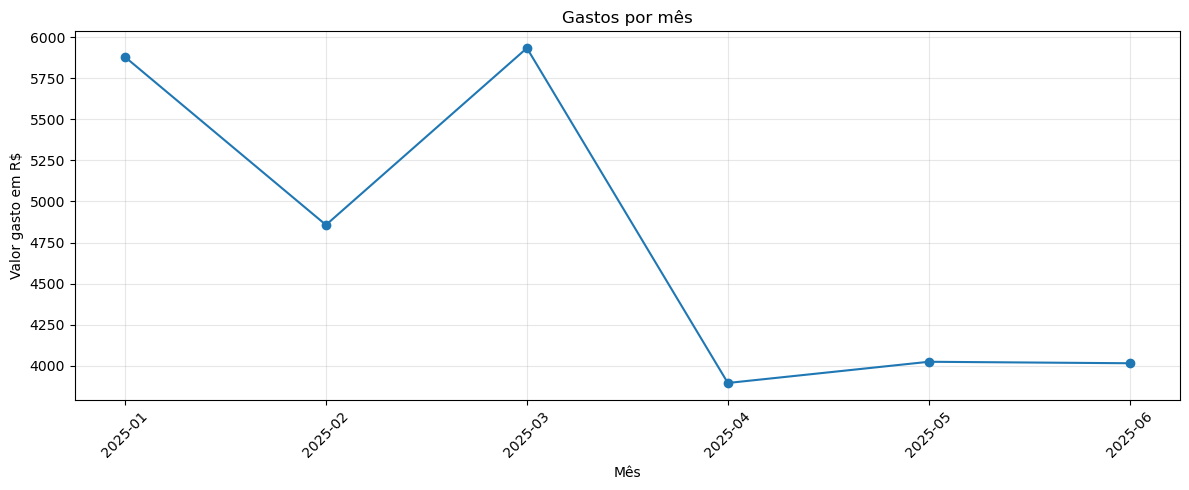


=== GASTOS POR CATEGORIA ===


,Total gasto
categoria,
Moradia,8951.43
Saúde,5683.48
Educação,4758.33
Alimentação,3769.81
Lazer,3554.00
Transporte,1888.17


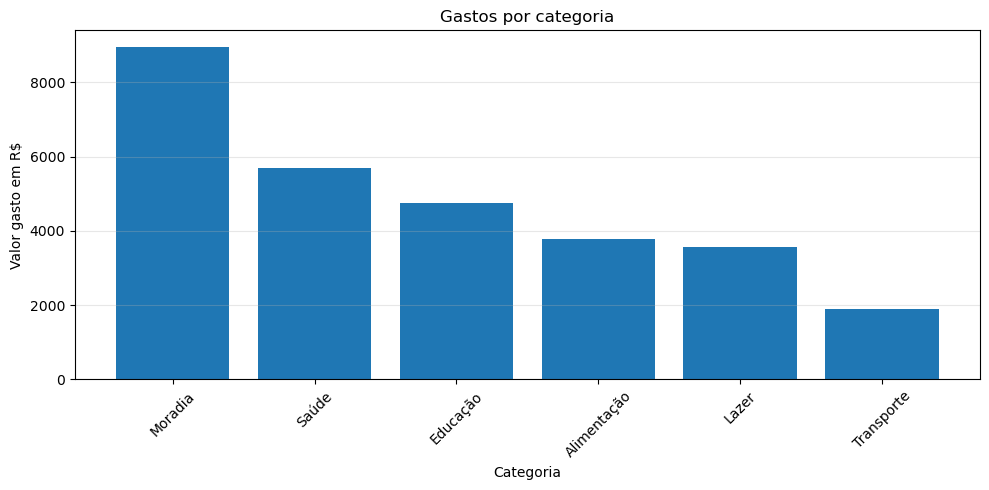


=== PARTICIPAÇÃO POR CATEGORIA ===


,Participação (%)
categoria,
Moradia,31.29
Saúde,19.87
Educação,16.63
Alimentação,13.18
Lazer,12.42
Transporte,6.60



=== ESTATÍSTICAS POR CATEGORIA ===


,total_gasto,media_gasto,maior_gasto,menor_gasto,quantidade
categoria,,,,,
Moradia,8951.43,203.44,298.10,104.12,44
Saúde,5683.48,129.17,199.50,56.51,44
Educação,4758.33,105.74,177.13,40.07,45
Alimentação,3769.81,81.95,149.29,20.66,46
Lazer,3554.00,72.53,118.62,22.43,49
Transporte,1888.17,43.91,79.74,11.63,43



=== TOP 10 MAIORES GASTOS ===


,data,categoria,descricao,valor
198,2025-05-02,Moradia,Gasto com Moradia,298.10
15,2025-01-10,Moradia,Gasto com Moradia,271.99
102,2025-02-28,Moradia,Gasto com Moradia,271.26
256,2025-06-16,Moradia,Gasto com Moradia,264.51
185,2025-04-22,Moradia,Gasto com Moradia,264.13
84,2025-02-20,Moradia,Gasto com Moradia,263.29
182,2025-04-21,Moradia,Gasto com Moradia,260.19
160,2025-04-01,Moradia,Gasto com Moradia,259.04
119,2025-03-11,Moradia,Gasto com Moradia,258.96
39,2025-01-22,Moradia,Gasto com Moradia,258.04



=== RANKING FINAL DAS CATEGORIAS ===


,total_gasto,media_gasto,maior_gasto,menor_gasto,quantidade,participacao_percentual
categoria,,,,,,
Moradia,8951.43,203.44,298.10,104.12,44,31.29
Saúde,5683.48,129.17,199.50,56.51,44,19.87
Educação,4758.33,105.74,177.13,40.07,45,16.63
Alimentação,3769.81,81.95,149.29,20.66,46,13.18
Lazer,3554.00,72.53,118.62,22.43,49,12.42
Transporte,1888.17,43.91,79.74,11.63,43,6.60



Análise concluída com sucesso.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1) CRIAR BASE FICTÍCIA DE GASTOS
# ------------------------------------------------------------

np.random.seed(42)

datas = pd.date_range(start="2025-01-01", end="2025-06-30", freq="D")

categorias = [
    "Alimentação",
    "Transporte",
    "Moradia",
    "Lazer",
    "Saúde",
    "Educação"
]

registros = []

for data in datas:
    quantidade_gastos_no_dia = np.random.randint(0, 4)

    for i in range(quantidade_gastos_no_dia):
        categoria = np.random.choice(categorias)

        if categoria == "Moradia":
            valor = np.random.uniform(100, 300)
        elif categoria == "Saúde":
            valor = np.random.uniform(50, 200)
        elif categoria == "Educação":
            valor = np.random.uniform(40, 180)
        elif categoria == "Alimentação":
            valor = np.random.uniform(20, 150)
        elif categoria == "Transporte":
            valor = np.random.uniform(10, 80)
        else:
            valor = np.random.uniform(20, 120)

        registros.append({
            "data": data,
            "categoria": categoria,
            "descricao": "Gasto com " + categoria,
            "valor": round(valor, 2)
        })

gastos = pd.DataFrame(registros)


# ------------------------------------------------------------
# 2) TRATAR OS DADOS
# ------------------------------------------------------------

gastos["data"] = pd.to_datetime(gastos["data"])
gastos["valor"] = pd.to_numeric(gastos["valor"])

gastos["ano_mes"] = gastos["data"].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# 3) VISUALIZAR A BASE
# ------------------------------------------------------------

print("Primeiras linhas da base de gastos:")
display(gastos.head())

print("\nÚltimas linhas da base de gastos:")
display(gastos.tail())


# ------------------------------------------------------------
# 4) RESUMO GERAL
# ------------------------------------------------------------

total_gasto = gastos["valor"].sum()
quantidade_lancamentos = len(gastos)
media_por_gasto = gastos["valor"].mean()
dias_com_gasto = gastos["data"].dt.date.nunique()
media_diaria = total_gasto / dias_com_gasto

maior_despesa = gastos.loc[gastos["valor"].idxmax()]

print("\n=== RESUMO GERAL ===")
print(f"Total gasto: R$ {total_gasto:,.2f}")
print(f"Quantidade de lançamentos: {quantidade_lancamentos}")
print(f"Média por gasto: R$ {media_por_gasto:,.2f}")
print(f"Dias com gasto: {dias_com_gasto}")
print(f"Média diária em dias com gasto: R$ {media_diaria:,.2f}")

print("\nMaior despesa:")
print(f"Data: {maior_despesa['data'].date()}")
print(f"Categoria: {maior_despesa['categoria']}")
print(f"Descrição: {maior_despesa['descricao']}")
print(f"Valor: R$ {maior_despesa['valor']:,.2f}")


# ------------------------------------------------------------
# 5) GASTOS POR MÊS
# ------------------------------------------------------------

gastos_por_mes = gastos.groupby("ano_mes")["valor"].sum().sort_index()

print("\n=== GASTOS POR MÊS ===")
display(gastos_por_mes.to_frame("Total gasto").round(2))

plt.figure(figsize=(12, 5))
plt.plot(gastos_por_mes.index, gastos_por_mes.values, marker="o")
plt.title("Gastos por mês")
plt.xlabel("Mês")
plt.ylabel("Valor gasto em R$")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6) GASTOS POR CATEGORIA
# ------------------------------------------------------------

gastos_por_categoria = gastos.groupby("categoria")["valor"].sum()
gastos_por_categoria = gastos_por_categoria.sort_values(ascending=False)

print("\n=== GASTOS POR CATEGORIA ===")
display(gastos_por_categoria.to_frame("Total gasto").round(2))

plt.figure(figsize=(10, 5))
plt.bar(gastos_por_categoria.index, gastos_por_categoria.values)
plt.title("Gastos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Valor gasto em R$")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) PARTICIPAÇÃO PERCENTUAL POR CATEGORIA
# ------------------------------------------------------------

participacao_categoria = gastos_por_categoria / total_gasto * 100

print("\n=== PARTICIPAÇÃO POR CATEGORIA ===")
display(participacao_categoria.to_frame("Participação (%)").round(2))


# ------------------------------------------------------------
# 8) ESTATÍSTICAS POR CATEGORIA
# ------------------------------------------------------------

estatisticas_categoria = gastos.groupby("categoria")["valor"].agg(
    total_gasto="sum",
    media_gasto="mean",
    maior_gasto="max",
    menor_gasto="min",
    quantidade="count"
)

estatisticas_categoria = estatisticas_categoria.sort_values(
    by="total_gasto",
    ascending=False
)

print("\n=== ESTATÍSTICAS POR CATEGORIA ===")
display(estatisticas_categoria.round(2))


# ------------------------------------------------------------
# 9) TOP 10 MAIORES GASTOS
# ------------------------------------------------------------

top_10_gastos = gastos.sort_values("valor", ascending=False).head(10)

print("\n=== TOP 10 MAIORES GASTOS ===")
display(top_10_gastos[["data", "categoria", "descricao", "valor"]])


# ------------------------------------------------------------
# 10) RANKING FINAL
# ------------------------------------------------------------

ranking_final = estatisticas_categoria.copy()
ranking_final["participacao_percentual"] = (
    ranking_final["total_gasto"] / total_gasto * 100
)

print("\n=== RANKING FINAL DAS CATEGORIAS ===")
display(ranking_final.round(2))

print("\nAnálise concluída com sucesso.")